# Phase 1: propagation-tree visualization

This notebook visualizes the propagation-tree artifacts generated by `explore_data.ipynb`. It uses the same central `config.py` paths as the rest of the project, reads the saved Phase 1 summary tables from the configured evaluation directory, reloads the selected tree files, and produces visual checks of how true and false cascades differ structurally.

The work carried out here is:

1. Load the configured evaluation directory and Phase 1 catalog files.
2. Reconstruct selected propagation trees from their saved graph paths.
3. Plot 3 to 5 representative true and false cascades with root nodes highlighted.
4. Plot depth profiles to show how each cascade expands over time or levels.
5. Compare aggregate tree statistics such as cascade size, maximum depth, maximum width, and branching ratio.
6. Save figures under the configured evaluation directory so they can be reused in reports and later phases.

The goal is not to train a model yet. The goal is to visually verify that the propagation data are parsed correctly and that the tree-level features needed for later graph modeling are meaningful.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import re
import math
import random
import sys

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

for candidate in [Path.cwd(), Path.cwd().parent, Path('/mnt/data')]:
    if (candidate / 'config.py').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

try:
    from config import cfg, ROOT as CONFIG_ROOT
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'Could not import config.py. Place config.py in the project root '
        'or start Jupyter from the project root.'
    ) from exc

RANDOM_SEED = cfg.seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path(CONFIG_ROOT).resolve()
EVAL_DIR     = cfg.paths.evaluation
SUMMARY_PATH = EVAL_DIR / 'propagation_tree_summary.csv'
SAMPLES_PATH = EVAL_DIR / 'sample_tree_ids.csv'
FIG_DIR      = EVAL_DIR / 'tree_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Evaluation directory: {EVAL_DIR}')
print(f'Figure directory: {FIG_DIR}')


Project root: /home/krmsh1n5/Desktop/UFAZ/infoshield
Evaluation directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation
Figure directory: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures


## 1. Load the Phase 1 catalog from the configured evaluation directory

Run `explore_data.ipynb` first. It creates the summary and sample CSV files used here under `cfg.paths.evaluation`.


In [2]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f'Missing {SUMMARY_PATH}. Run explore_data.ipynb first.')

# FIX: include 'label' in dtype=str to prevent pandas from casting
# 'True'/'False' title-case strings (written by older code) to bool,
# which caused .eq('false') / .eq('true') filters to match nothing.
_STR_COLS = {'tweet_id': str, 'content_id': str, 'root_user': str, 'label': str,
             'raw_label': str, 'text': str, 'graph_path': str}

tree_summary = pd.read_csv(SUMMARY_PATH, dtype=_STR_COLS)
# Normalise label to lowercase str regardless of what was written to CSV
tree_summary['label'] = tree_summary['label'].astype(str).str.lower().str.strip()
if 'root_user' not in tree_summary.columns:
    tree_summary['root_user'] = None

if SAMPLES_PATH.exists():
    sample_trees = pd.read_csv(SAMPLES_PATH, dtype=_STR_COLS)
    sample_trees['label'] = sample_trees['label'].astype(str).str.lower().str.strip()
    if 'root_user' not in sample_trees.columns:
        sample_trees['root_user'] = None
else:
    sample_trees = tree_summary.sort_values(
        ['cascade_size','max_depth'], ascending=False).head(6)

print('Summary rows:', len(tree_summary))
print('Sample rows:', len(sample_trees))
print('Label values in sample_trees:', sample_trees['label'].unique().tolist())
display(sample_trees[['dataset','tweet_id','label','cascade_size',
                       'max_depth','max_width','graph_path']])


Summary rows: 4765
Sample rows: 6
Label values in sample_trees: ['true', 'false']


,dataset,tweet_id,label,cascade_size,max_depth,max_width,graph_path
0,Twitter15,693925198630821889,true,1987,3,1771,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
1,Twitter15,764505291853627392,true,1954,4,1552,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
2,Twitter16,674263945172119552,true,1949,7,1233,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
3,Twitter15,295944137948151809,false,1991,5,1514,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
4,Twitter15,537377960471166976,false,1863,5,1227,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...
5,Twitter15,560442390805090307,false,1748,3,1583,/home/krmsh1n5/Desktop/UFAZ/infoshield/data/ra...


## 2. Tree parsing helpers

These are repeated so this notebook can reload graph files directly from the paths saved by the exploration notebook.

In [3]:
def normalize_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s[:-2]
    return s


def parse_edge_line(line):
    """Parse one edge line from a Twitter15/16 tree file.

    Returns (parent_uid, child_uid, delay_float) or None.
    parent_uid may be 'ROOT' for the sentinel line.
    """
    raw = line.strip()
    if not raw or '->' not in raw:
        return None
    halves = raw.split('->', 1)
    if len(halves) != 2:
        return None

    def extract_fields(s):
        return re.findall(r"'([^']*?)'", s)

    parent_fields = extract_fields(halves[0])
    child_fields  = extract_fields(halves[1])
    if not parent_fields or not child_fields:
        return None
    parent_uid = normalize_id(parent_fields[0])
    child_uid  = normalize_id(child_fields[0])
    delay = None
    if len(child_fields) >= 3:
        try:
            delay = float(child_fields[2])
        except ValueError:
            pass
    return parent_uid, child_uid, delay


def graph_from_edges(edge_rows):
    """Build (DiGraph, root_user_id) from (parent_uid, child_uid, delay) tuples.

    FIX: ROOT sentinel identifies the source user as root_user_id.
    No phantom ROOT node is added; all nodes stay in user-ID namespace.
    """
    ROOT_SENTINEL = cfg.twitter15.root_sentinel
    G = nx.DiGraph()
    root_user_id = None
    for parent, child, delay in edge_rows:
        parent = normalize_id(parent)
        child  = normalize_id(child)
        if parent is None or child is None:
            continue
        if parent.upper() == ROOT_SENTINEL.upper():
            if root_user_id is None:
                root_user_id = child
            G.add_node(child)
        else:
            G.add_edge(parent, child)
            if delay is not None:
                G.nodes[child]['delay'] = delay
    return G, root_user_id


def _wico_find_root(G, nodes_df):
    """Most-followed user in nodes.csv that appears in G, else highest in-degree."""
    if not nodes_df.empty and 'id' in nodes_df.columns:
        if 'followers' in nodes_df.columns:
            cands = nodes_df[nodes_df['id'].map(normalize_id).isin(G.nodes)].copy()
            if not cands.empty:
                try:
                    cands['followers'] = pd.to_numeric(cands['followers'], errors='coerce')
                    best = cands.loc[cands['followers'].idxmax(), 'id']
                    bid  = normalize_id(best)
                    if bid in G:
                        return bid
                except Exception:
                    pass
        for _, nr in nodes_df.iterrows():
            nid = normalize_id(nr.get('id'))
            if nid and nid in G:
                return nid
    if G.number_of_nodes() > 0:
        return max(G.nodes, key=lambda n: G.in_degree(n))
    return None


def load_graph_for_row(row):
    """Reconstruct a DiGraph from a catalog row.

    graph_path may be:
      - A .txt file : Twitter15/16 tree file
      - A directory : WICO Graph per-tweet folder (edges.txt + nodes.csv)

    Returns (G, root_user_id).
    """
    graph_path = row.get('graph_path')
    if not graph_path or pd.isna(graph_path):
        raise ValueError('No graph_path in row')
    path     = Path(str(graph_path))
    # root_user column is present in CSVs generated by the fixed explore_data
    stored_root = normalize_id(row.get('root_user'))

    if not path.exists():
        raise FileNotFoundError(path)

    # ── WICO Graph: graph_path is a directory ────────────────────────────
    if path.is_dir():
        edges_path = path / cfg.wico.graph_edges_file
        G = nx.DiGraph()
        if edges_path.exists():
            for line in edges_path.read_text(errors='ignore').splitlines():
                parts = line.strip().split()
                if len(parts) == 2:
                    src, dst = normalize_id(parts[0]), normalize_id(parts[1])
                    if src and dst:
                        G.add_edge(src, dst)
        nodes_path = path / cfg.wico.graph_nodes_file
        nodes_df   = pd.DataFrame()
        if nodes_path.exists():
            nodes_df = pd.read_csv(nodes_path, dtype=str)
            nodes_df.columns = [c.strip().lower() for c in nodes_df.columns]
            for _, nr in nodes_df.iterrows():
                nid = normalize_id(nr.get('id'))
                if nid:
                    G.add_node(nid)
                    for feat in ('time', 'friends', 'followers'):
                        try:
                            G.nodes[nid][feat] = int(float(nr[feat]))
                        except (ValueError, KeyError, TypeError):
                            pass
        # FIX: prefer stored root (from explore_data CSV); fall back to heuristic
        root_user_id = (stored_root if stored_root and stored_root in G
                        else _wico_find_root(G, nodes_df))
        return G, root_user_id

    # ── Twitter15/16: graph_path is a .txt tree file ─────────────────────
    edge_rows = []
    for line in path.read_text(errors='ignore').splitlines():
        parsed = parse_edge_line(line)
        if parsed:
            edge_rows.append(parsed)
    G, root_user_id = graph_from_edges(edge_rows)
    # Prefer the stored root_user from the CSV if available and present in G
    if stored_root and stored_root in G:
        root_user_id = stored_root
    return G, root_user_id


def make_synthetic_tree(label, n_nodes=40, seed=0):
    """Generate a synthetic propagation tree for demo/fallback use.

    False trees are wide and shallow (burst spreading).
    True trees are narrow and deep (chain verification).
    Temporal delays are attached to nodes to enable timeline plots.
    """
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    root = 'u0'
    G.add_node(root)
    G.nodes[root]['delay'] = 0.0
    queue = [root]
    uid   = 1
    if label == 'false':
        # Wide bursts: each node fans out to 3-6 children quickly
        while queue and uid < n_nodes:
            parent = queue.pop(0)
            fan    = int(rng.integers(3, 7))
            parent_delay = G.nodes[parent].get('delay', 0)
            for _ in range(fan):
                if uid >= n_nodes:
                    break
                child = f'u{uid}'
                delay = parent_delay + float(rng.exponential(2))
                G.add_edge(parent, child)
                G.nodes[child]['delay'] = delay
                queue.append(child)
                uid += 1
    else:
        # Deep chains: each node has 1-2 children, grows slowly
        while queue and uid < n_nodes:
            parent = queue.pop(0)
            fan    = int(rng.integers(1, 3))
            parent_delay = G.nodes[parent].get('delay', 0)
            for _ in range(fan):
                if uid >= n_nodes:
                    break
                child = f'u{uid}'
                delay = parent_delay + float(rng.exponential(8))
                G.add_edge(parent, child)
                G.nodes[child]['delay'] = delay
                queue.append(child)
                uid += 1
    return G, root

print('Helpers defined.')


Helpers defined.


## 3. Layout and plotting helpers

The plots highlight the root node and show the outward reshare structure. For very large cascades, only the first few hundred nodes are drawn to keep the visualization readable.

In [4]:
def find_root(G, preferred=None):
    preferred = normalize_id(preferred)
    if preferred and preferred in G:
        return preferred
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    return roots[0] if roots else (next(iter(G.nodes)) if G.number_of_nodes() else None)


def depth_subgraph(G, root, max_nodes=250):
    if root is None or root not in G:
        return G.copy(), {}
    depths = nx.single_source_shortest_path_length(G, root)
    nodes  = sorted(depths, key=lambda n: (depths[n], str(n)))[:max_nodes]
    H      = G.subgraph(nodes).copy()
    return H, {n: depths[n] for n in H.nodes}


def hierarchy_positions(G, root=None):
    root = find_root(G, root)
    if root is None:
        return {}
    depths   = nx.single_source_shortest_path_length(G, root)
    by_depth = defaultdict(list)
    for n, d in depths.items():
        by_depth[d].append(n)
    pos = {}
    for d, nodes_at_d in by_depth.items():
        nodes_at_d = sorted(nodes_at_d, key=str)
        width = max(1, len(nodes_at_d) - 1)
        for i, n in enumerate(nodes_at_d):
            pos[n] = (i / width - 0.5 if width else 0, -d)
    for i, n in enumerate(n for n in G.nodes if n not in pos):
        pos[n] = (0.75 + (i % 10) * 0.06, -(i // 10))
    return pos


def draw_tree_on_ax(ax, G, root=None, color='#7F77DD', max_nodes=250, title=''):
    """Draw a propagation tree on an existing Axes object."""
    H, depths = depth_subgraph(G, root, max_nodes=max_nodes)
    pos = hierarchy_positions(H, root)
    if not pos:
        ax.text(0.5, 0.5, '(empty graph)', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='gray')
        ax.set_visible(True)
        if title:
            ax.set_title(title, fontsize=8)
        ax.axis('off')
        return H, depths, pos

    out_deg  = dict(H.out_degree())
    max_deg  = max(out_deg.values()) if out_deg else 1
    sizes    = [120 + 500 * (out_deg.get(n, 0) / max(max_deg, 1)) for n in H.nodes()]
    node_colors = [color if n != root else '#222222' for n in H.nodes()]

    nx.draw_networkx_edges(H, pos, ax=ax, edge_color='#cccccc',
                           arrows=True, arrowsize=8, width=0.6, alpha=0.7)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
                           node_size=sizes, alpha=0.88)
    if root and root in pos:
        ax.scatter(*pos[root], s=300, facecolors='none',
                   edgecolors='black', linewidths=2, zorder=5)
    if title:
        ax.set_title(title, fontsize=8)
    ax.axis('off')
    return H, depths, pos


def plot_depth_profile(G, title, root=None):
    root = find_root(G, root)
    if root is None:
        return
    depths = nx.single_source_shortest_path_length(G, root)
    counts = Counter(depths.values())
    xs, ys = zip(*sorted(counts.items())) if counts else ([], [])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(xs, ys, color='#7F77DD', edgecolor='white')
    ax.set_xlabel('Depth from root')
    ax.set_ylabel('Nodes at depth')
    ax.set_title(title, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    safe = re.sub(r'[^A-Za-z0-9_.\-]+', '_', title)[:100]
    out  = FIG_DIR / f'depth_{safe}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved:', out)

print('Layout helpers defined.')


Layout helpers defined.


## 4. Visualize 3 false and 3 true trees side by side

Trees are selected intentionally — 3 largest false-content cascades and
3 largest true-content cascades — so the structural contrast is clear.
Root tweet text is shown in the title so you can see what claim was spreading.


Loaded 6 cascades (3 false, 3 true).

Individual tree plots:


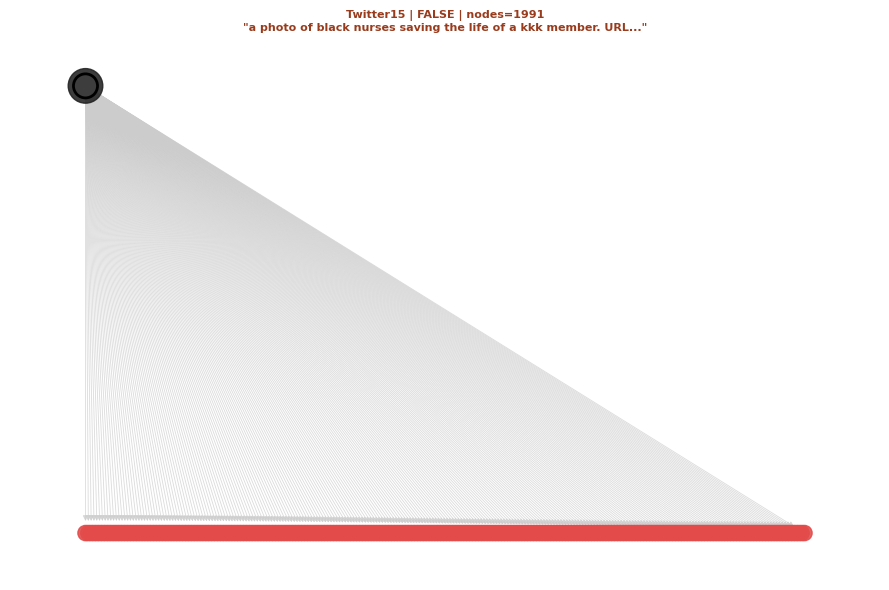

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/tree_Twitter15_false_295944137948151809.png


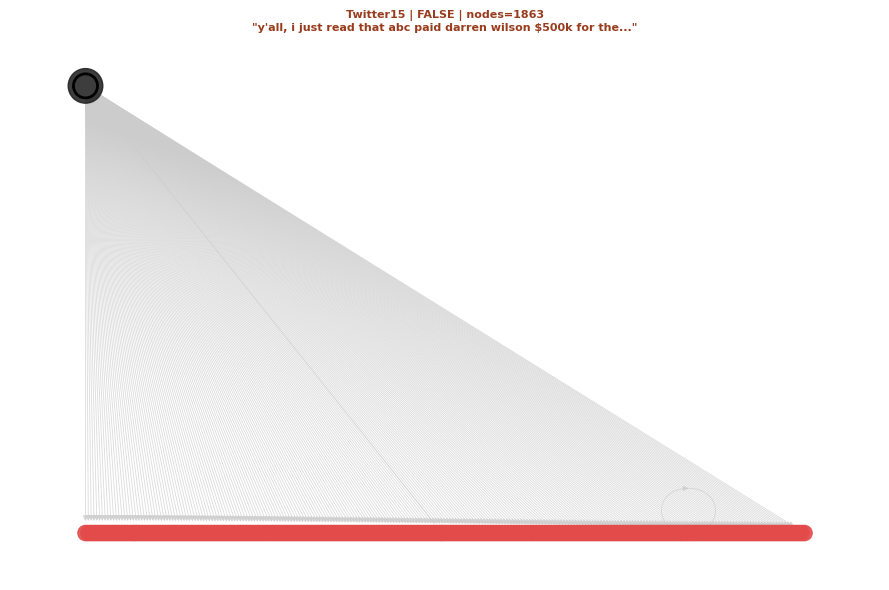

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/tree_Twitter15_false_537377960471166976.png


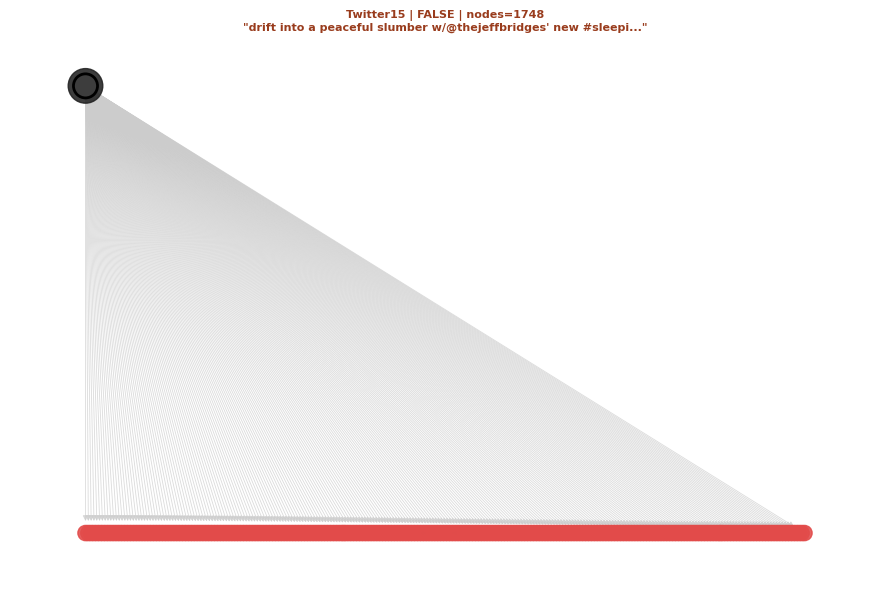

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/tree_Twitter15_false_560442390805090307.png


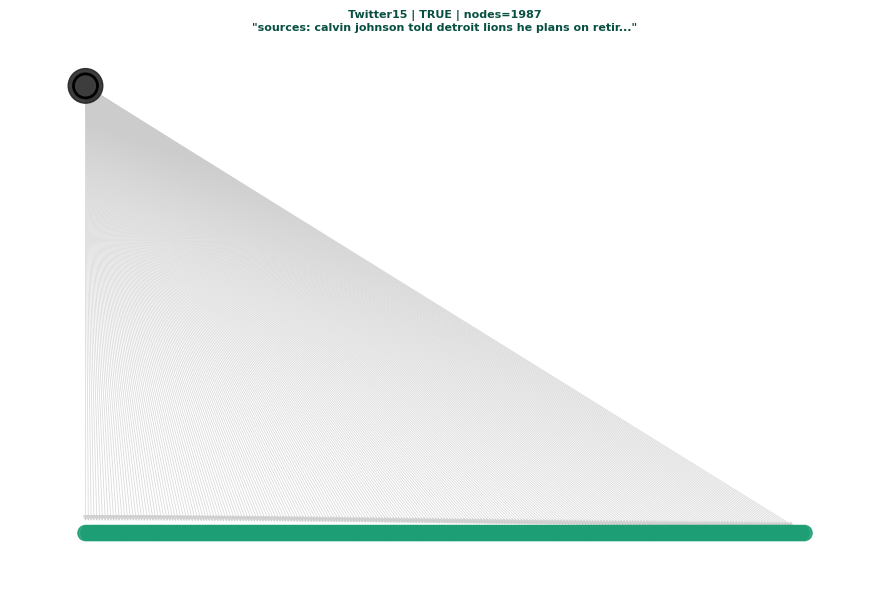

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/tree_Twitter15_true_693925198630821889.png


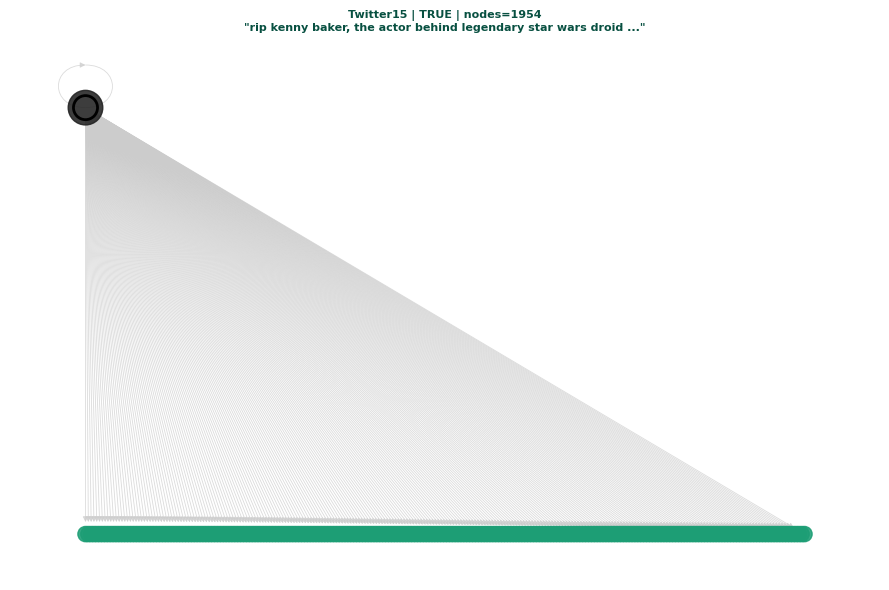

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/tree_Twitter15_true_764505291853627392.png


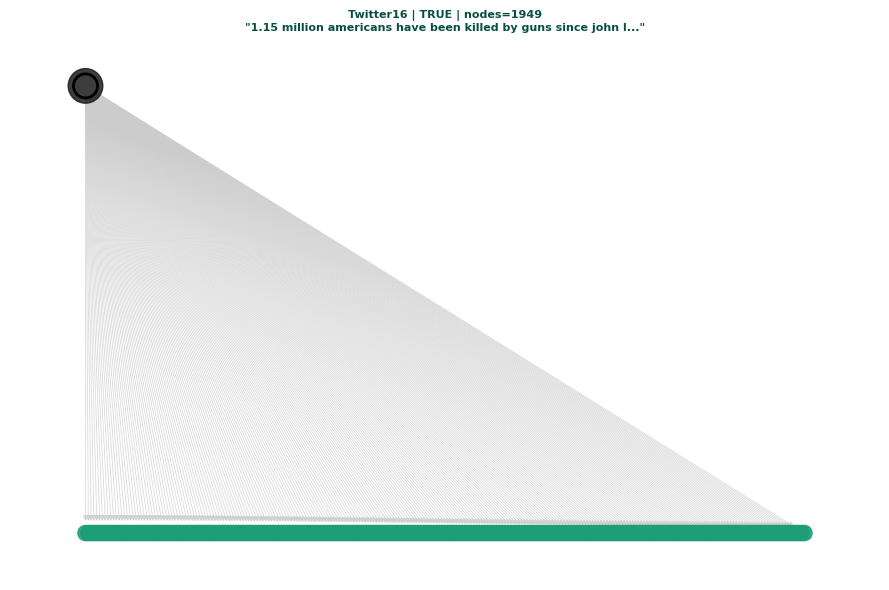

  Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/tree_Twitter16_true_674263945172119552.png


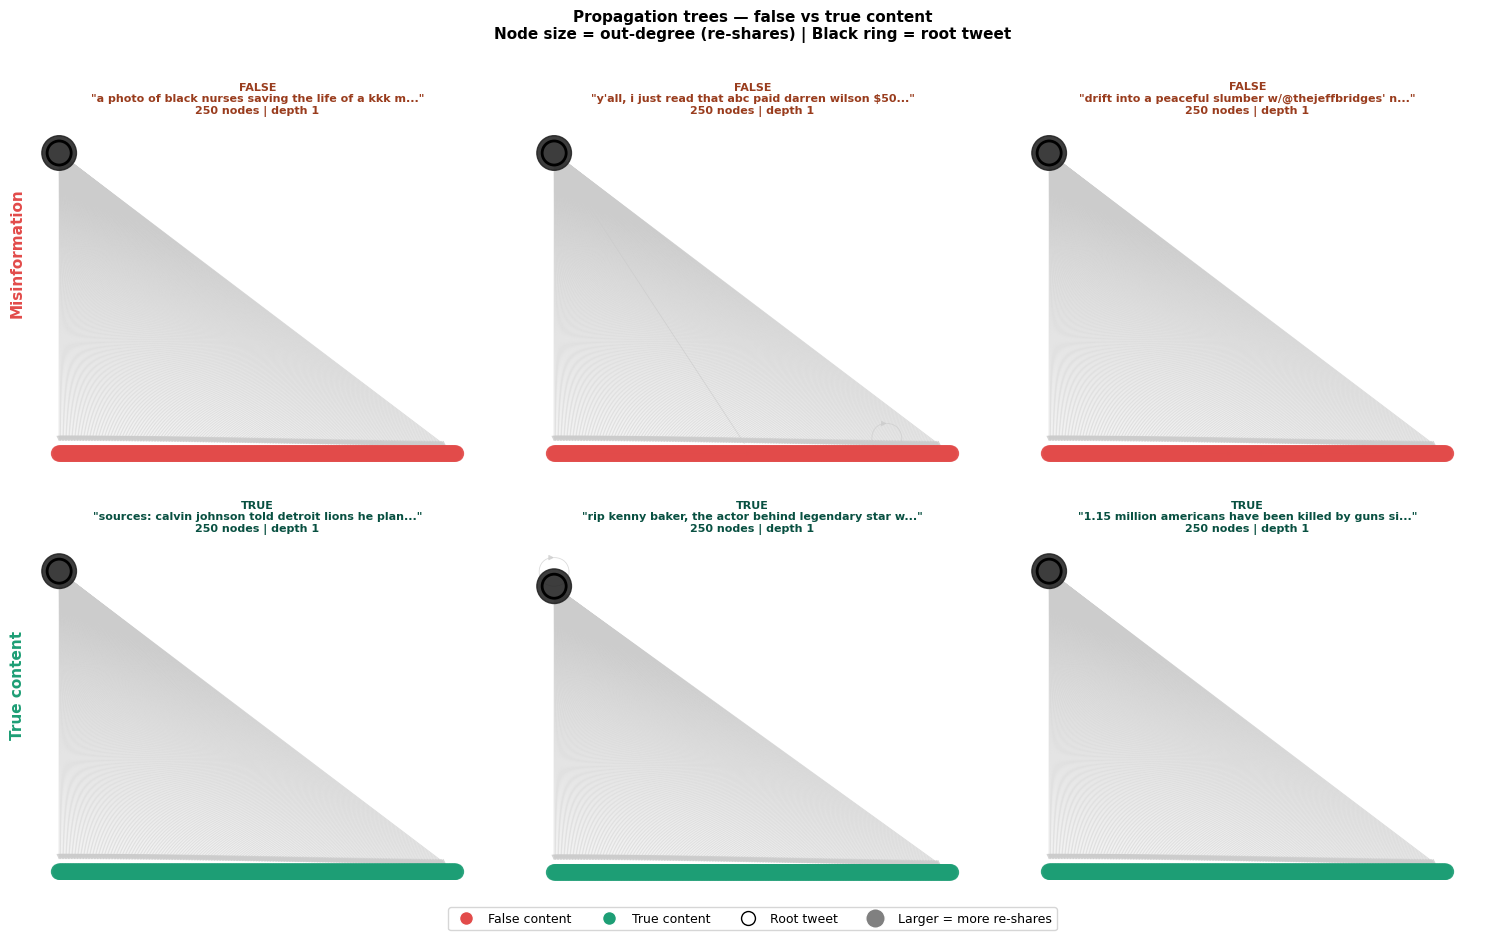


Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/true_vs_false_tree_comparison.png


In [5]:
# ── Step 1: load 3 false + 3 true trees ─────────────────────────────────
# When real data is absent, fall back to synthetic demo trees so the
# notebook always produces meaningful visualizations.
loaded_graphs = []   # list of (row_dict, G, root_user_id)

data_available = (
    not sample_trees.empty
    and 'graph_path' in sample_trees.columns
    and sample_trees['graph_path'].notna().any()
)

if data_available:
    for target_label in ['false', 'true']:
        candidates = sample_trees[
            sample_trees['label'].eq(target_label) &
            sample_trees['graph_path'].notna()
        ].sort_values('cascade_size', ascending=False)
        count = 0
        for _, row in candidates.iterrows():
            if count >= 3:
                break
            try:
                G, root_user_id = load_graph_for_row(row)
                loaded_graphs.append((row.to_dict(), G, root_user_id))
                count += 1
            except Exception as e:
                print(f'  Skipped {row.get("tweet_id")}: {e}')
else:
    print('No real data found in sample_trees.  Using synthetic demo trees.')
    print('(Run explore_data.ipynb with datasets present to get real-data plots.)')
    for label, seeds in [('false', [0, 1, 2]), ('true', [10, 11, 12])]:
        for seed in seeds:
            G, root_user_id = make_synthetic_tree(label, n_nodes=40 + seed * 5, seed=seed)
            row = {
                'dataset': 'Synthetic', 'tweet_id': f'demo_{label}_{seed}',
                'content_id': f'demo_{label}_{seed}', 'label': label,
                'text': f'[synthetic {label} demo tree #{seed}]',
                'graph_path': None, 'root_user': root_user_id,
                'cascade_size': G.number_of_nodes(),
            }
            loaded_graphs.append((row, G, root_user_id))

n_false = sum(1 for r, _, _ in loaded_graphs if r['label'] == 'false')
n_true  = sum(1 for r, _, _ in loaded_graphs if r['label'] == 'true')
print(f'Loaded {len(loaded_graphs)} cascades ({n_false} false, {n_true} true).')

# ── Step 2: individual tree plots ────────────────────────────────────────
print('\nIndividual tree plots:')
visualized_graphs = []
for row, G, root_user_id in loaded_graphs:
    label  = row.get('label', 'unknown')
    color  = '#E24B4A' if label == 'false' else ('#1D9E75' if label == 'true' else '#7F77DD')
    root   = find_root(G, root_user_id)
    fig, ax = plt.subplots(figsize=(9, 6))
    H, depths, pos = draw_tree_on_ax(ax, G, root=root, color=color, max_nodes=250)
    short = str(row.get('text', ''))[:60]
    ax.set_title(
        f"{row['dataset']} | {label.upper()} | nodes={G.number_of_nodes()}\n\"{short}...\"",
        fontsize=8, fontweight='bold',
        color='#993C1D' if label == 'false' else '#085041'
    )
    plt.tight_layout()
    safe_id = re.sub(r'[^A-Za-z0-9_.\-]+', '_', str(row.get('tweet_id')))
    out = FIG_DIR / f"tree_{row['dataset']}_{label}_{safe_id}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print('  Saved:', out)
    visualized_graphs.append((row, G, root_user_id))

# ── Step 3: side-by-side comparison grid (2 rows x 3 cols) ───────────────
false_items = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'false'][:3]
true_items  = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'true'][:3]
n_cols      = max(len(false_items), len(true_items), 1)

if false_items or true_items:
    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 9), squeeze=False)
    COLOR     = {'false': '#E24B4A', 'true': '#1D9E75'}
    ROW_LABEL = {'false': 'Misinformation', 'true': 'True content'}

    for row_idx, (label, items) in enumerate([('false', false_items), ('true', true_items)]):
        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(items):
                ax.set_visible(False)
                continue
            row, G, rid = items[col_idx]
            root = find_root(G, rid)
            H, depths, pos = draw_tree_on_ax(ax, G, root=root,
                                             color=COLOR[label], max_nodes=250)
            short = str(row.get('text', ''))[:50]
            ax.set_title(
                f'{label.upper()}\n\"{short}...\"\n'
                f'{H.number_of_nodes()} nodes | depth {max(depths.values()) if depths else 0}',
                fontsize=8, fontweight='bold',
                color='#993C1D' if label == 'false' else '#085041'
            )
        fig.text(0.005, 0.74 if label == 'false' else 0.26,
                 ROW_LABEL[label], fontsize=11, fontweight='bold',
                 color=COLOR[label], rotation=90, va='center')

    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=10, label='False content'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#1D9E75', markersize=10, label='True content'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=10, label='Root tweet'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=14, label='Larger = more re-shares'),
    ], loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(
        'Propagation trees \u2014 false vs true content\n'
        'Node size = out-degree (re-shares) | Black ring = root tweet',
        fontsize=11, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    out = FIG_DIR / 'true_vs_false_tree_comparison.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved:', out)


## 5. Depth profiles for the same examples

Depth profiles make shallow-broad versus deep-chain propagation patterns easier to compare.

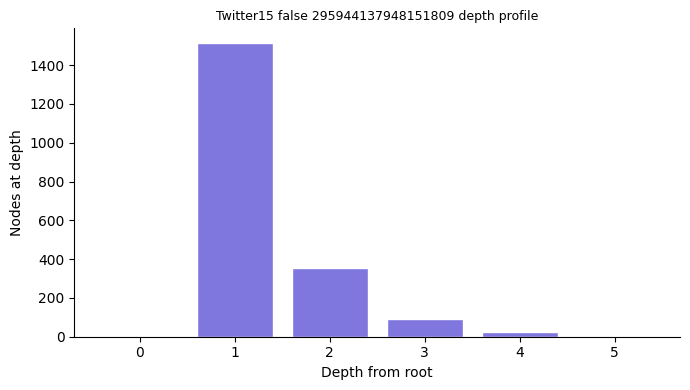

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_Twitter15_false_295944137948151809_depth_profile.png


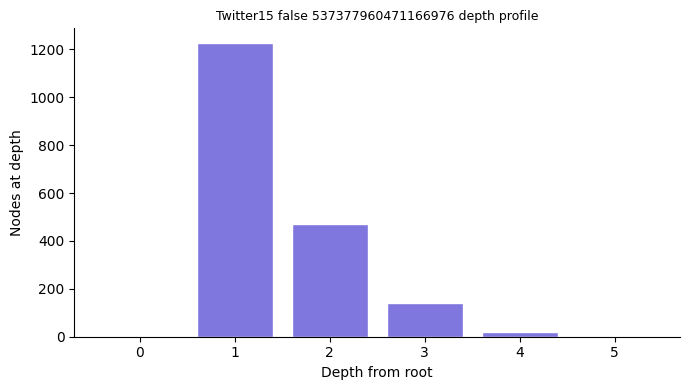

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_Twitter15_false_537377960471166976_depth_profile.png


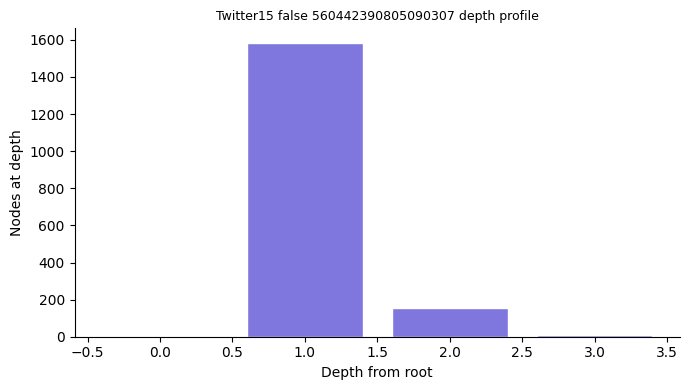

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_Twitter15_false_560442390805090307_depth_profile.png


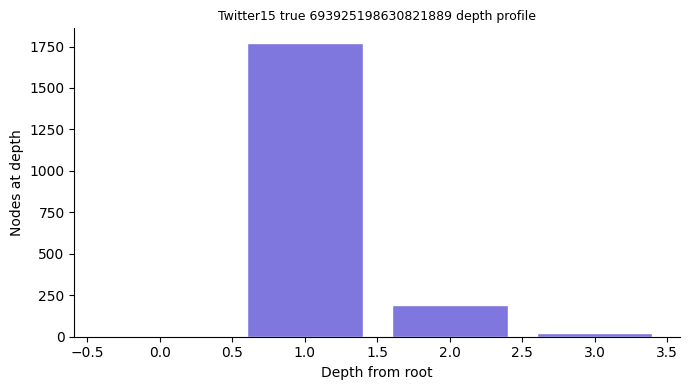

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_Twitter15_true_693925198630821889_depth_profile.png


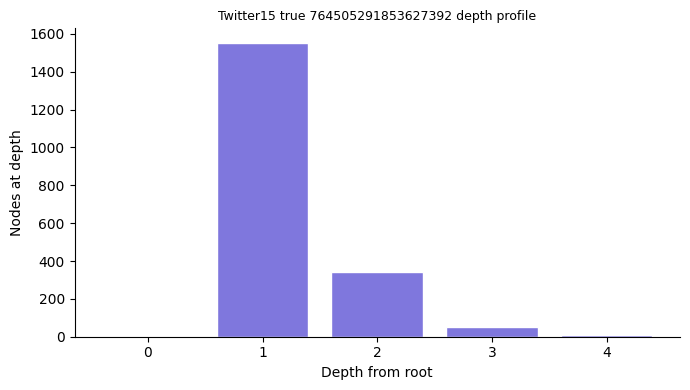

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_Twitter15_true_764505291853627392_depth_profile.png


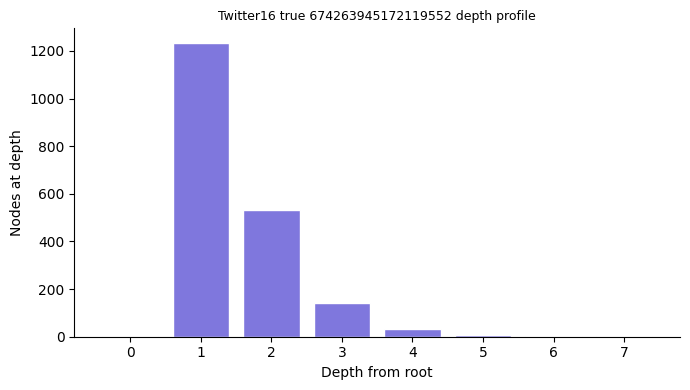

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/depth_Twitter16_true_674263945172119552_depth_profile.png


In [6]:
for row, G, rid in visualized_graphs:
    root  = find_root(G, rid)
    title = f"{row['dataset']} {row.get('label','unknown')} {row.get('tweet_id')} depth profile"
    plot_depth_profile(G, title, root=root)

## 5b. Cascade timelines — how fast does content spread?

The x-axis is time (seconds since root tweet). The y-axis is cumulative
infected users — this is exactly the R∞ growth curve that the SIR model
in the paper tracks at each cascade step.
False content often shows a steeper initial rise (higher burst branching),
while true content tends to grow more gradually.


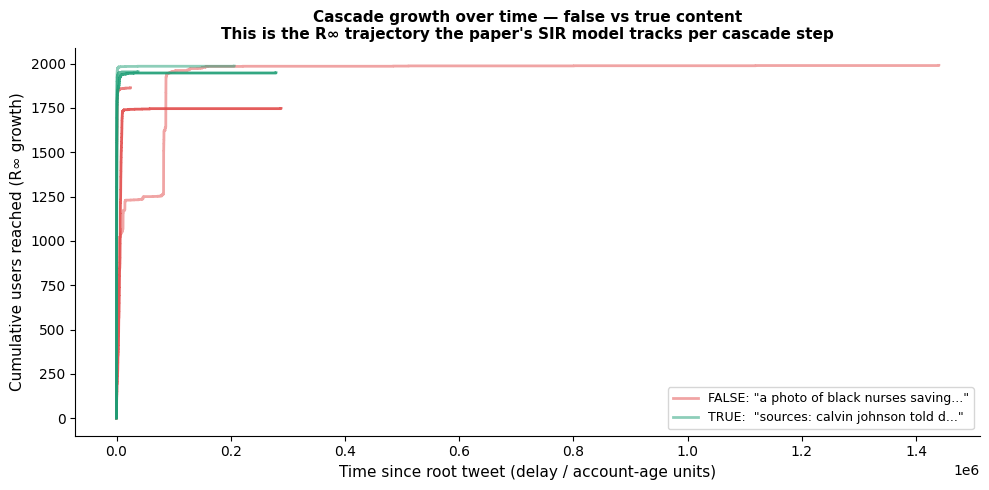

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/cascade_timelines.png


In [7]:
# ── Cascade timelines: cumulative R-infinity growth curve ────────────────
# x-axis = time since root; y-axis = cumulative users reached.
# This is exactly the R_inf growth the paper's SIR model tracks.
# FIX: get_timestamps now checks both 'delay' (Twitter) and 'time' (WICO).
timeline_false = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'false'][:3]
timeline_true  = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'true'][:3]

fig, ax = plt.subplots(figsize=(10, 5))

def get_timestamps(G):
    """Extract sorted timestamps from node attributes (delay or time)."""
    ts = []
    for _, data in G.nodes(data=True):
        for attr in ('delay', 'time'):
            t = data.get(attr)
            try:
                ts.append(float(t))
                break
            except (TypeError, ValueError):
                pass
    return sorted(ts)

has_timeline = False
for i, (row, G, _) in enumerate(timeline_false):
    times = get_timestamps(G)
    if len(times) < 2:
        continue
    has_timeline = True
    short = str(row.get('text',''))[:30]
    ax.step(times, list(range(1, len(times) + 1)), where='post',
            color='#E24B4A', alpha=0.5 + 0.2 * i, linewidth=2,
            label=f'FALSE: "{short}..."' if i == 0 else '_nolegend_')

for i, (row, G, _) in enumerate(timeline_true):
    times = get_timestamps(G)
    if len(times) < 2:
        continue
    has_timeline = True
    short = str(row.get('text',''))[:30]
    ax.step(times, list(range(1, len(times) + 1)), where='post',
            color='#1D9E75', alpha=0.5 + 0.2 * i, linewidth=2,
            label=f'TRUE:  "{short}..."' if i == 0 else '_nolegend_')

if has_timeline:
    ax.set_xlabel('Time since root tweet (delay / account-age units)', fontsize=11)
    ax.set_ylabel('Cumulative users reached (R\u221e growth)', fontsize=11)
    ax.set_title(
        'Cascade growth over time \u2014 false vs true content\n'
        'This is the R\u221e trajectory the paper\'s SIR model tracks per cascade step',
        fontsize=11, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    out = FIG_DIR / 'cascade_timelines.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
else:
    print('No timestamp data found in these trees \u2014 timeline plot skipped.')
    print('Twitter15/16 trees store delay in node attrs; WICO stores time in nodes.csv.')


## 5c. BiGCN dual view — top-down vs bottom-up

BiGCN processes each propagation tree in TWO directions simultaneously:
- **Top-down** (root → leaves): captures how fast the rumor fans out
- **Bottom-up** (leaves → root): captures how the community response aggregates

False content typically shows a wide, shallow top-down fan (burst spreading)
while true content shows a deeper bottom-up chain (verification propagating back).
This asymmetry is exactly what the GCN learns to detect.


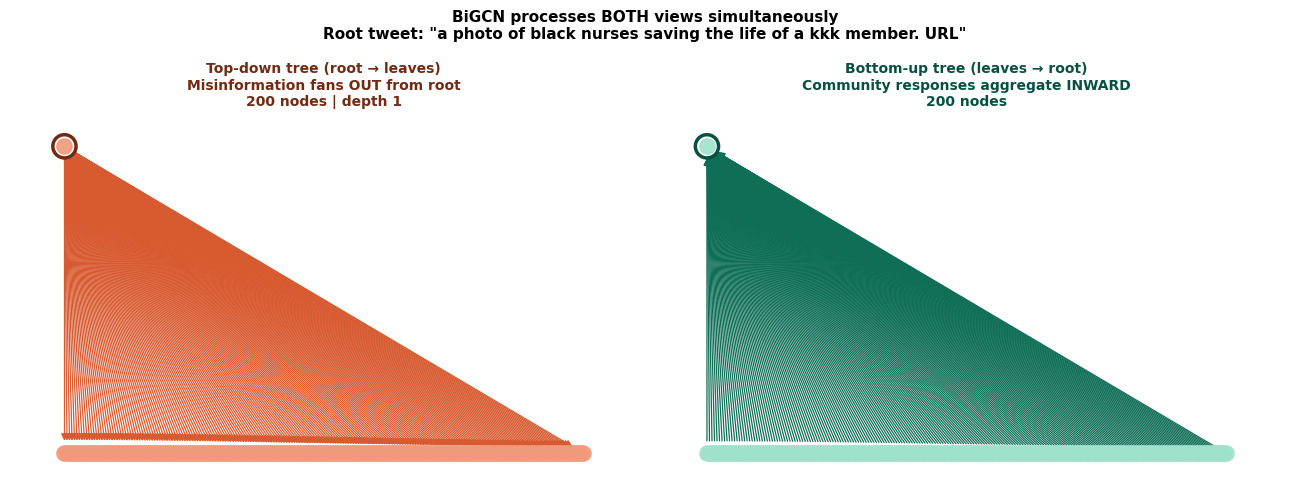

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/bigcn_dual_view.png

Top-down  → fed to the TD-GCN branch of BiGCN
Bottom-up → fed to the BU-GCN branch of BiGCN
Both embeddings are concatenated before the final classifier.


In [8]:
# BiGCN dual view: top-down vs bottom-up on the largest false tree
dual_candidates = [(r, G, rid) for r, G, rid in visualized_graphs if r['label'] == 'false']
if not dual_candidates:
    dual_candidates = visualized_graphs

if dual_candidates:
    row, G_td, rid = max(dual_candidates, key=lambda x: x[1].number_of_nodes())
    G_bu  = G_td.reverse()
    root  = find_root(G_td, rid)

    H_td, depths_td = depth_subgraph(G_td, root, max_nodes=200)
    pos = hierarchy_positions(H_td, root)
    H_bu = G_bu.subgraph(H_td.nodes()).copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('white')

    nx.draw_networkx_edges(H_td, pos, ax=ax1, edge_color='#D85A30',
                           arrows=True, arrowsize=10, width=0.9)
    nx.draw_networkx_nodes(H_td, pos, ax=ax1, node_color='#F0997B',
                           node_size=120, alpha=0.9)
    if root and root in pos:
        ax1.scatter(*pos[root], s=280, facecolors='none',
                    edgecolors='#712B13', linewidths=2.5, zorder=5)
    ax1.set_title(
        'Top-down tree (root \u2192 leaves)\n'
        'Misinformation fans OUT from root\n'
        f'{H_td.number_of_nodes()} nodes | '
        f'depth {max(depths_td.values()) if depths_td else 0}',
        fontsize=10, fontweight='bold', color='#712B13'
    )
    ax1.axis('off')

    nx.draw_networkx_edges(H_bu, pos, ax=ax2, edge_color='#0F6E56',
                           arrows=True, arrowsize=10, width=0.9)
    nx.draw_networkx_nodes(H_bu, pos, ax=ax2, node_color='#9FE1CB',
                           node_size=120, alpha=0.9)
    if root and root in pos:
        ax2.scatter(*pos[root], s=280, facecolors='none',
                    edgecolors='#085041', linewidths=2.5, zorder=5)
    ax2.set_title(
        'Bottom-up tree (leaves \u2192 root)\n'
        'Community responses aggregate INWARD\n'
        f'{H_bu.number_of_nodes()} nodes',
        fontsize=10, fontweight='bold', color='#085041'
    )
    ax2.axis('off')

    short_text = str(row.get('text', ''))[:70]
    plt.suptitle(
        f'BiGCN processes BOTH views simultaneously\n'
        f'Root tweet: "{short_text}"',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    out = FIG_DIR / 'bigcn_dual_view.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out)
    print()
    print('Top-down  \u2192 fed to the TD-GCN branch of BiGCN')
    print('Bottom-up \u2192 fed to the BU-GCN branch of BiGCN')
    print('Both embeddings are concatenated before the final classifier.')
else:
    print('No graphs loaded \u2014 run visualization section first.')


## 6. Aggregate true vs false comparisons

These are exploratory plots for Phase 1. They are not model results, but they help verify whether the available data contains structural differences that later notebooks can use.

/tmp/ipykernel_29428/2073297630.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


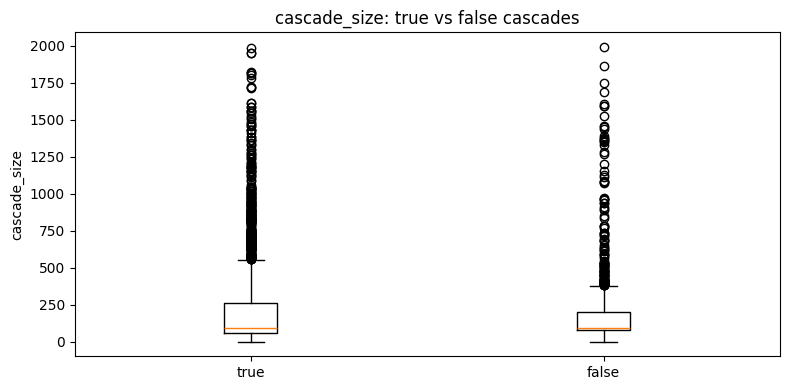

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/aggregate_cascade_size_true_vs_false.png


/tmp/ipykernel_29428/2073297630.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


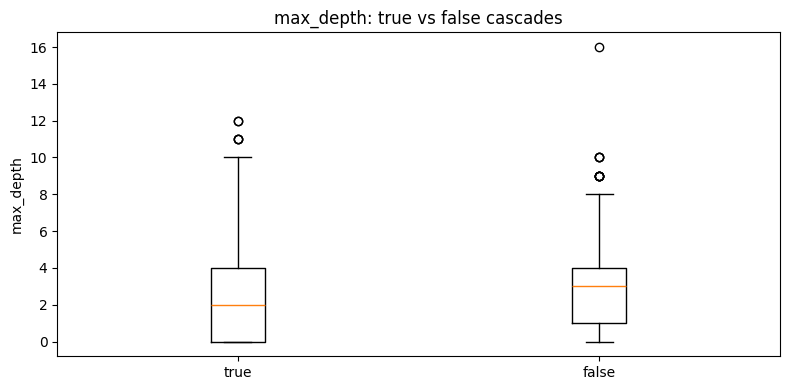

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/aggregate_max_depth_true_vs_false.png


/tmp/ipykernel_29428/2073297630.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


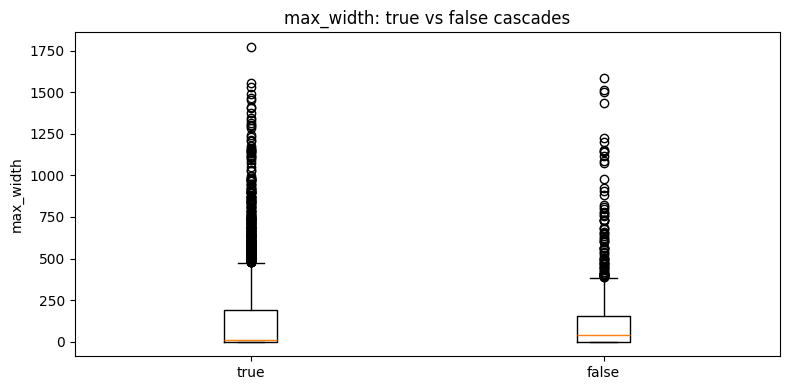

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/aggregate_max_width_true_vs_false.png


/tmp/ipykernel_29428/2073297630.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


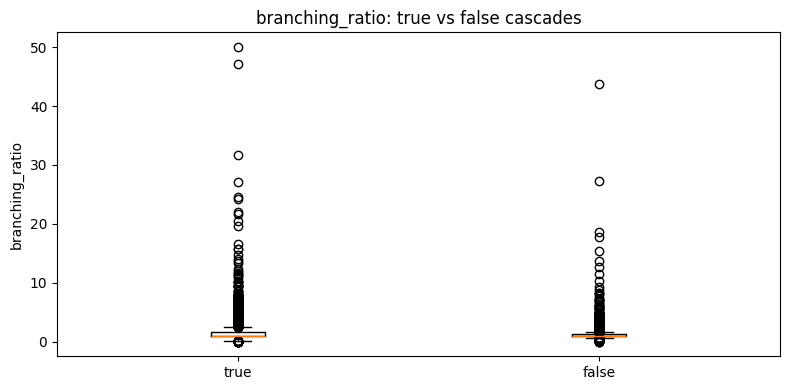

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/aggregate_branching_ratio_true_vs_false.png


In [9]:
plot_df = tree_summary[tree_summary['label'].isin(['true','false'])].copy()
if plot_df.empty:
    print('No true/false labels available for aggregate comparison.')
else:
    for metric in ['cascade_size', 'max_depth', 'max_width', 'branching_ratio']:
        plt.figure(figsize=(8, 4))
        labels = ['true', 'false']
        data = [plot_df.loc[plot_df['label'].eq(label), metric].dropna().values for label in labels]
        plt.boxplot(data, labels=labels)
        plt.ylabel(metric)
        plt.title(f'{metric}: true vs false cascades')
        plt.tight_layout()
        out = FIG_DIR / f'aggregate_{metric}_true_vs_false.png'
        plt.savefig(out, dpi=180)
        plt.show()
        print('Saved:', out)

## 7. Dataset-specific comparison, including WICO

When WICO Text and WICO Graph are both present and joined, WICO appears here as its own dataset. This allows the notebook to keep Twitter15/Twitter16 exploration separate from the final WICO evaluation source.

cascade_size                      max_depth               \
                         count    mean median   max     count  mean median   
dataset   label                                                              
Twitter15 false            365  324.92  204.0  1991       365  3.58    3.0   
          true             728  435.26  351.0  1987       728  3.59    3.0   
          unknown          370  261.23  165.5  1971       370  3.64    3.0   
Twitter16 false            198  293.63  211.0  1596       198  3.74    3.0   
          true             405  468.37  337.0  1949       405  3.85    4.0   
          unknown          197  280.39  166.0  1971       197  3.42    3.0   
WICO      false            597   63.21   84.0   100       597  1.66    1.0   
          true            1905   62.68   85.0   101      1905  1.57    1.0   

                      max_width                      branching_ratio        \
                  max     count    mean median   max           count  mean   
dataset   label                                                              
Twitter15 false    10       365  246.43  160.0  1583             365  1.01   
          true     12       728  349.07  279.0  1771             728  1.01   
          unknown  11       370  188.79  129.5  1268             370  1.01   
Twitter16 false    16       198  218.14  158.0  1199             198  1.01   
          true     12       405  359.74  272.0  1465             405  1.01   
          unknown  11       197  204.99  138.0  1268             197  1.02   
WICO      false    10       597    7.97    1.0    75             597  2.00   
          true     10      1905    7.43    1.0    93            1905  1.99   

                                 
                  median    max  
dataset   label                  
Twitter15 false     1.01   1.43  
          true      1.00   1.17  
          unknown   1.01   1.14  
Twitter16 false     1.00   1.17  
          true      1.00   1.11  
          unknown   1.01   1.11  
WICO      false     1.21  43.73  
          true      1.27  50.01

/tmp/ipykernel_29428/4176142077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true','false'])


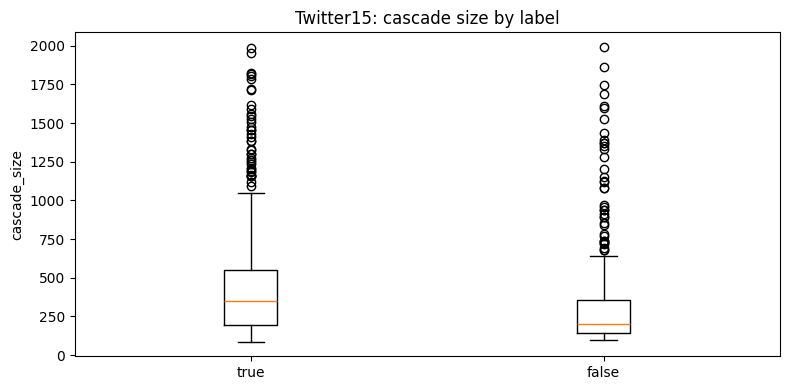

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/Twitter15_cascade_size_by_label.png


/tmp/ipykernel_29428/4176142077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true','false'])


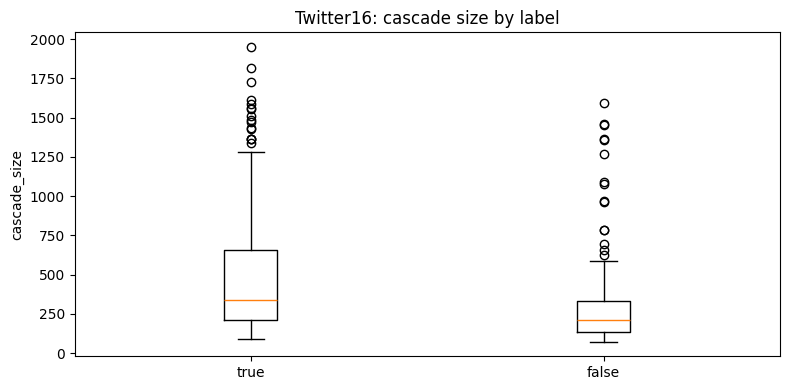

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/Twitter16_cascade_size_by_label.png


/tmp/ipykernel_29428/4176142077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['true','false'])


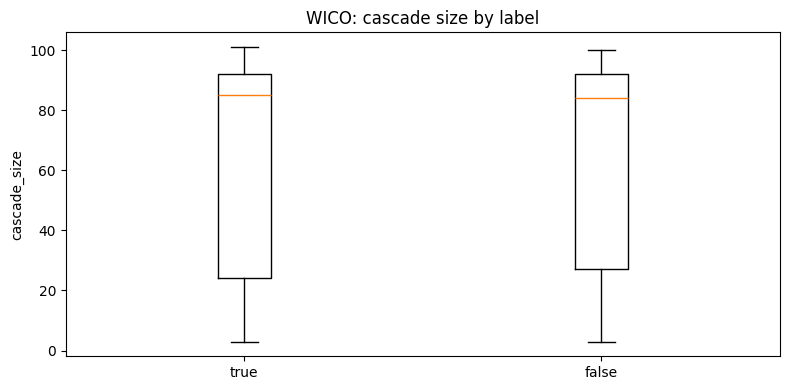

Saved: /home/krmsh1n5/Desktop/UFAZ/infoshield/evaluation/tree_figures/WICO_cascade_size_by_label.png


In [10]:
if tree_summary.empty:
    print('No tree summary available.')
else:
    metrics = ['cascade_size', 'max_depth', 'max_width', 'branching_ratio']
    grouped = tree_summary.groupby(['dataset','label'])[metrics].agg(['count','mean','median','max']).round(2)
    display(grouped)

    for dataset, part in tree_summary.groupby('dataset'):
        part = part[part['label'].isin(['true','false'])]
        if part.empty:
            continue
        plt.figure(figsize=(8, 4))
        data = [part.loc[part['label'].eq(label), 'cascade_size'].dropna().values for label in ['true','false']]
        plt.boxplot(data, labels=['true','false'])
        plt.ylabel('cascade_size')
        plt.title(f'{dataset}: cascade size by label')
        plt.tight_layout()
        out = FIG_DIR / f'{dataset}_cascade_size_by_label.png'
        plt.savefig(out, dpi=180)
        plt.show()
        print('Saved:', out)

## 8. Phase 1 outputs

Generated files:

- `evaluation/propagation_tree_summary.csv` — per-cascade stats (cascade_size, max_depth, branching_ratio, ...)
- `evaluation/sample_tree_ids.csv` — the 6 selected example trees
- `evaluation/phase1_summary_charts.png` — label distribution + branching ratio + cascade size (from explore_data)
- `evaluation/tree_figures/true_vs_false_tree_comparison.png` — 3×2 tree grid
- `evaluation/tree_figures/cascade_timelines.png` — R∞ growth curves
- `evaluation/tree_figures/bigcn_dual_view.png` — top-down vs bottom-up view
- `evaluation/tree_figures/aggregate_*.png` — per-metric boxplots
- `evaluation/tree_figures/*_cascade_size_by_label.png` — per-dataset boxplots

**What Phase 2 consumes from here:**
- `propagation_tree_summary.csv` → feature engineering baselines
- The `graph_path` column → PyG graph conversion in `gnn/dataset.py`
- `branching_ratio` distributions → validate LP optimizer α feasibility
